In [2]:
import pandas as pd

# Load raw datasets
orders = pd.read_csv('../data/olist_orders_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
items = pd.read_csv('../data/olist_order_items_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')

# Keep only delivered orders — these are the ones with complete purchase data
orders_clean = orders[orders['order_status'] == 'delivered'].copy()

# Convert date columns to datetime
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col])

# Aggregate payments per order — one row per order
payments_agg = (
    payments
    .groupby('order_id')
    .agg(
        total_payment=('payment_value', 'sum'),
        payment_installments=('payment_installments', 'max')
    )
    .reset_index()
)

# Aggregate items per order — one row per order
items_agg = (
    items
    .groupby('order_id')
    .agg(
        item_count=('order_item_id', 'count'),
        avg_price=('price', 'mean'),
        total_freight=('freight_value', 'sum')
    )
    .reset_index()
)

# Build the master dataframe
df = (
    orders_clean
    .merge(customers, on='customer_id')
    .merge(payments_agg, on='order_id')
    .merge(items_agg, on='order_id')
)

# Feature: how many days it took to deliver
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

print(f"Dataset shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Dataset shape: (96477, 18)

Missing values:
order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
customer_unique_id                0
customer_zip_code_prefix          0
customer_city                     0
customer_state                    0
total_payment                     0
payment_installments              0
item_count                        0
avg_price                         0
total_freight                     0
delivery_days                     8
dtype: int64


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment,payment_installments,item_count,avg_price,total_freight,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,1,1,29.99,8.72,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1,1,118.70,22.76,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,3,1,159.90,19.22,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,1,1,45.00,27.20,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,1,1,19.90,8.72,2.0


In [3]:
# Drop rows where delivery date is missing — we can't calculate delivery time without it
df = df.dropna(subset=['order_delivered_customer_date', 'delivery_days'])

# For order_approved_at, fill with purchase timestamp — minimal impact (14 rows)
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
df['order_approved_at'] = df['order_approved_at'].fillna(df['order_purchase_timestamp'])

# Sanity check
print(f"Clean dataset shape: {df.shape}")
print(f"Date range: {df['order_purchase_timestamp'].min()} → {df['order_purchase_timestamp'].max()}")
print(f"Avg order value: ${df['total_payment'].mean():.2f}")
print(f"Avg delivery time: {df['delivery_days'].mean():.1f} days")

Clean dataset shape: (96469, 18)
Date range: 2016-10-03 09:44:50 → 2018-08-29 15:00:37
Avg order value: $159.86
Avg delivery time: 12.1 days


In [4]:
import numpy as np

# Set reference date — one day after the last purchase in the dataset
reference_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Build RFM table at the customer level
rfm = (
    df.groupby('customer_unique_id')
    .agg(
        recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
        frequency=('order_id', 'count'),
        monetary=('total_payment', 'sum'),
        avg_order_value=('total_payment', 'mean'),
        avg_items_per_order=('item_count', 'mean'),
        avg_delivery_days=('delivery_days', 'mean'),
        avg_freight=('total_freight', 'mean'),
        uses_installments=('payment_installments', lambda x: (x > 1).mean()),
        first_purchase=('order_purchase_timestamp', 'min'),
        last_purchase=('order_purchase_timestamp', 'max'),
    )
    .reset_index()
)

# Customer lifespan in days
rfm['customer_lifespan'] = (rfm['last_purchase'] - rfm['first_purchase']).dt.days

# Average days between orders — only meaningful for repeat customers
rfm['avg_days_between_orders'] = np.where(
    rfm['frequency'] > 1,
    rfm['customer_lifespan'] / (rfm['frequency'] - 1),
    np.nan
)

print(f"Unique customers: {rfm.shape[0]:,}")
print(f"\nRepeat customers: {(rfm['frequency'] > 1).sum():,} ({(rfm['frequency'] > 1).mean()*100:.1f}%)")
print(f"\nRFM summary:")
print(rfm[['recency','frequency','monetary','avg_order_value']].describe().round(2))

Unique customers: 93,349

Repeat customers: 2,801 (3.0%)

RFM summary:
        recency  frequency  monetary  avg_order_value
count  93349.00   93349.00  93349.00         93349.00
mean     237.94       1.03    165.20           160.32
std      152.58       0.21    226.32           219.58
min        1.00       1.00      9.59             9.59
25%      114.00       1.00     63.05            62.37
50%      219.00       1.00    107.78           105.63
75%      346.00       1.00    182.55           176.65
max      695.00      15.00  13664.08         13664.08


In [5]:
# Score each RFM dimension on a 1-5 scale
# Recency: lower is better (more recent = higher score)
rfm['R_score'] = pd.qcut(rfm['recency'], q=5, labels=[5,4,3,2,1]).astype(int)

# Frequency & Monetary: higher is better
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1,2,3,4,5]).astype(int)

# Composite RFM score
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# Segment customers based on RFM score
def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Recent Customers'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cant Lose Them'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'Potential Loyalists'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

# Segment summary
segment_summary = (
    rfm.groupby('segment')
    .agg(
        customer_count=('customer_unique_id', 'count'),
        avg_monetary=('monetary', 'mean'),
        avg_recency=('recency', 'mean'),
        avg_frequency=('frequency', 'mean'),
        total_revenue=('monetary', 'sum')
    )
    .round(2)
    .sort_values('total_revenue', ascending=False)
)

segment_summary['revenue_share_%'] = (
    segment_summary['total_revenue'] / segment_summary['total_revenue'].sum() * 100
).round(1)

print(segment_summary)

                     customer_count  avg_monetary  avg_recency  avg_frequency  \
segment                                                                         
At Risk                       13164        243.53       393.50           1.07   
Loyal Customers               14207        207.10       153.23           1.05   
Recent Customers              14980        163.42        90.89           1.00   
Lost                          14986        162.96       395.51           1.00   
Potential Loyalists           29520         79.82       236.28           1.01   
Champions                      6492        312.15        91.12           1.18   

                     total_revenue  revenue_share_%  
segment                                              
At Risk                 3205790.21             20.8  
Loyal Customers         2942330.64             19.1  
Recent Customers        2448079.38             15.9  
Lost                    2442065.65             15.8  
Potential Loyalists     235

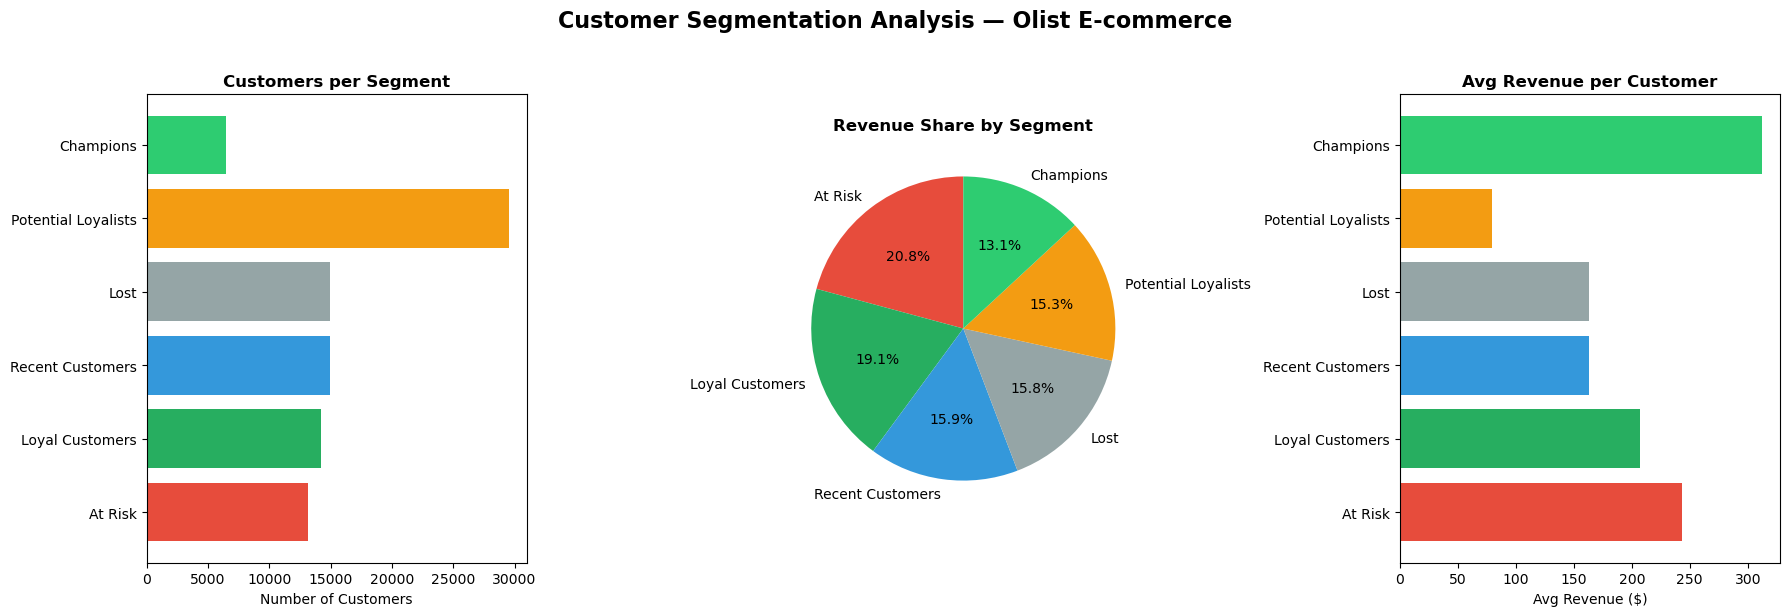

Saved to outputs/segment_overview.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Customer Segmentation Analysis — Olist E-commerce', fontsize=16, fontweight='bold', y=1.02)

# Color palette per segment
colors = {
    'Champions': '#2ecc71',
    'Loyal Customers': '#27ae60',
    'Recent Customers': '#3498db',
    'Potential Loyalists': '#f39c12',
    'At Risk': '#e74c3c',
    'Lost': '#95a5a6'
}
segment_colors = [colors[s] for s in segment_summary.index]

# Plot 1: Customer count per segment
axes[0].barh(segment_summary.index, segment_summary['customer_count'], color=segment_colors)
axes[0].set_title('Customers per Segment', fontweight='bold')
axes[0].set_xlabel('Number of Customers')

# Plot 2: Revenue share per segment
axes[1].pie(
    segment_summary['revenue_share_%'],
    labels=segment_summary.index,
    colors=segment_colors,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Revenue Share by Segment', fontweight='bold')

# Plot 3: Avg monetary value per segment
axes[2].barh(segment_summary.index, segment_summary['avg_monetary'], color=segment_colors)
axes[2].set_title('Avg Revenue per Customer', fontweight='bold')
axes[2].set_xlabel('Avg Revenue ($)')

plt.tight_layout()
plt.savefig('../outputs/segment_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/segment_overview.png")

In [7]:
rfm.to_csv('../data/rfm_clean.csv', index=False)
print("RFM saved.")

RFM saved.
